# **Predicting Future Stock Prices (Short-Term) Using Historical Stock Data**

# DevelopersHub Corporation  - Machine Learning Interneship - Task-2 
## Name: Muhammad Irfan Shafique - ID: DHC-2046

## Importing packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from IPython.display import display, HTML
from matplotlib.ticker import MultipleLocator
from sklearn.model_selection import train_test_split,learning_curve,cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import mplfinance as mpf
import os



pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")

## Downloading Apple Inc. Stock Data from Yahoo Finance
#### **Period - Jan 1, 2015 to Apr 19, 2026**

## Creating CSV file - Apple Stock Data 

In [2]:
file_path = "apple_stock_data.csv"
ticker = "AAPL"

# Download ONLY if file doesn't exist

if not os.path.exists(file_path):
    print("Downloading data...")

    df = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-04-19",
        auto_adjust=True
    )

    # ensure index is clean datetime BEFORE saving
    df.index = pd.to_datetime(df.index)

    df.to_csv(file_path)
    print("CSV created successfully!")

else:
    print("CSV already exists. Skipping download.")


CSV already exists. Skipping download.


## Reading Apple Stock Data from CSV file

In [3]:
# Load CSV safely

df_ap = pd.read_csv("apple_stock_data.csv", skiprows=[0,1])

df_ap.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

df_ap["Date"] = pd.to_datetime(df_ap["Date"], format="%Y-%m-%d")

df_ap.set_index("Date", inplace=True)

## Dataset Overview & Statistical Summary

#### Dataset Features

**Date:** Date - The trading day  

**Close:** Final price of the stock at the end of the trading day  

**High:** The highest price of the stock reached during the trading day  
     
**Low:** The lowest price of the stock during the trading day  

**Open:** Price of the stock at the start of the trading day   

**Volume:** Number of shares traded during the trading day      


In [4]:
df_ap.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


**Number of Rows and Columns in the Dataset**

In [5]:
rows, cols = df_ap.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 2839
Number of columns: 5


In [6]:
df_ap.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2839 entries, 2015-01-02 to 2026-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2839 non-null   float64
 1   High    2839 non-null   float64
 2   Low     2839 non-null   float64
 3   Open    2839 non-null   float64
 4   Volume  2839 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 133.1 KB


In [7]:
df_ap.duplicated()

Date
2015-01-02    False
2015-01-05    False
2015-01-06    False
2015-01-07    False
2015-01-08    False
              ...  
2026-04-13    False
2026-04-14    False
2026-04-15    False
2026-04-16    False
2026-04-17    False
Length: 2839, dtype: bool

**No Duplicate Rows**

In [8]:
desc = df_ap.describe()
desc = desc.apply(lambda col: col.map(lambda x: f"{x:.2f}"))
display(HTML("<h4><b>Statistical Summary</b></h4>"))
display(desc)

,Close,High,Low,Open,Volume
count,2839.00,2839.00,2839.00,2839.00,2839.00
mean,110.18,111.28,108.98,110.09,109743619.37
std,77.25,78.00,76.43,77.18,67974133.70
min,20.58,20.89,20.39,20.51,17910600.00
25%,37.13,37.45,36.75,37.12,62587600.00
50%,108.55,109.98,106.41,108.71,92844800.00
75%,171.19,172.25,169.28,170.94,135483000.00
max,285.92,288.35,283.04,285.93,648825200.00


# EDA (Exploratory Data Analysis)

In [9]:
missing_values = df_ap.isnull().sum().to_frame(name="Missing/Null Values")

display(HTML("<h4><b>Missing / Null Values Summary</b></h4>"))
display(missing_values)

,Missing/Null Values
Close,0
High,0
Low,0
Open,0
Volume,0


##### **NO Missing/NULL values found**

## **Historic Data Visualization**

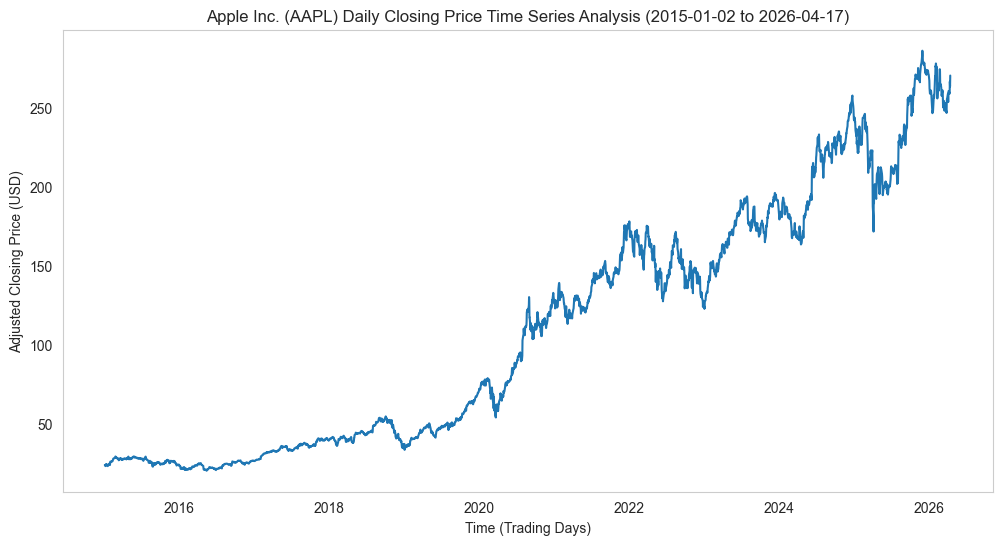

In [10]:
start_date = df_ap.index.min().date()
end_date = df_ap.index.max().date()

plt.figure(figsize=(12,6))
plt.plot(df_ap.index, df_ap["Close"])

plt.title(f"Apple Inc. (AAPL) Daily Closing Price Time Series Analysis ({start_date} to {end_date})")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Adjusted Closing Price (USD)")
plt.grid()

plt.show()

## **Feature Engineering**

In [11]:
# Lag features 
df_ap['Close_Lag1'] = df_ap['Close'].shift(1)
df_ap['Close_Lag2'] = df_ap['Close'].shift(2)
df_ap['Close_Lag3'] = df_ap['Close'].shift(3)


# Moving average (trend)
df_ap['MA_3'] = df_ap['Close'].rolling(window=3).mean()


# Volatility / range
df_ap['HL_Range'] = df_ap['High'] - df_ap['Low']   


# Returns (momentum)
df_ap['Return_1'] = df_ap['Close'].pct_change(1)



# Price position 
df_ap['Close_to_High'] = df_ap['Close'] / df_ap['High']
df_ap['Close_to_Low'] = df_ap['Close'] / df_ap['Low']


# Volatility 
df_ap['Volatility_3'] = df_ap['Close'].rolling(3).std()

# Drop missing values
df_ap = df_ap.dropna()

rows, cols = df_ap.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

pd.set_option('display.float_format', '{:.6f}'.format)
df_ap.head().T

Number of rows: 2836
Number of columns: 14


Date,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13
Close,23.864948,24.781891,24.808470,24.197176,24.412016
High,23.964616,24.839477,25.083110,24.945793,24.983446
Low,23.632389,24.075355,24.409797,24.097509,24.121872
Open,23.743131,24.192743,24.954649,24.939149,24.680012
Volume,160423600.000000,237458000.000000,214798000.000000,198603200.000000,268367600.000000
Close_Lag1,23.534935,23.864948,24.781891,24.808470,24.197176
Close_Lag2,23.532719,23.534935,23.864948,24.781891,24.808470
Close_Lag3,24.214886,23.532719,23.534935,23.864948,24.781891
MA_3,23.644201,24.060591,24.485103,24.595846,24.472554
HL_Range,0.332227,0.764122,0.673313,0.848284,0.861574


In [12]:
df_ap.tail().T

Date,2026-04-13,2026-04-14,2026-04-15,2026-04-16,2026-04-17
Close,259.200012,258.829987,266.429993,263.399994,270.230011
High,260.179993,261.929993,266.559998,267.160004,272.299988
Low,256.660004,257.190002,257.809998,261.269989,266.720001
Open,259.730011,259.250000,258.160004,266.799988,266.959991
Volume,36234700.000000,48370700.000000,49913500.000000,43323100.000000,61436200.000000
Close_Lag1,260.480011,259.200012,258.829987,266.429993,263.399994
Close_Lag2,260.489990,260.480011,259.200012,258.829987,266.429993
Close_Lag3,258.899994,260.489990,260.480011,259.200012,258.829987
MA_3,260.056671,259.503337,261.486664,262.886658,266.686666
HL_Range,3.519989,4.739990,8.750000,5.890015,5.579987


## **Daily Closing Price and Moving Average**

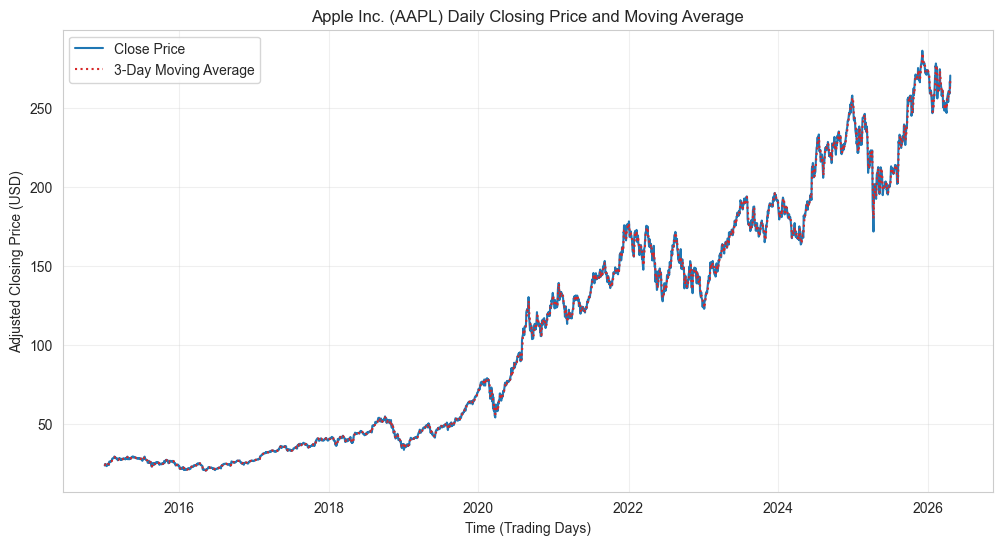

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    df_ap.index,
    df_ap["Close"],
    color='#1f77b4',
    label='Close Price'
)

plt.plot(
    df_ap.index,
    df_ap["MA_3"],
    color='#d62728',
    linestyle=":",
    label='3-Day Moving Average'
)

plt.title("Apple Inc. (AAPL) Daily Closing Price and Moving Average")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Adjusted Closing Price (USD)")
plt.grid(alpha=0.3)

plt.legend()  

plt.show()

## **Daily High-Low Prices**

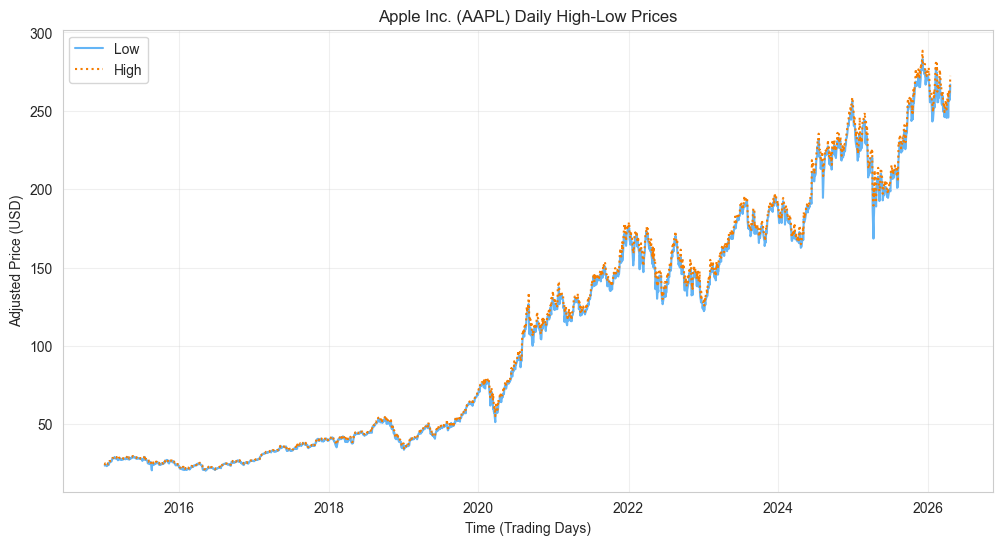

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    df_ap.index,
    df_ap["Low"],
    color='#64B5F6',
    label='Low'
)

plt.plot(
    df_ap.index,
    df_ap["High"],
    color='#F57C00',
    linestyle=":",
    label='High'
)

plt.title("Apple Inc. (AAPL) Daily High-Low Prices")
plt.xlabel("Time (Trading Days)")
plt.ylabel("Adjusted Price (USD)")
plt.grid(alpha=0.3)

plt.legend()  

plt.show()

## **Closing Price vs Lagged Features (Time-Series Dependency Analysis)**

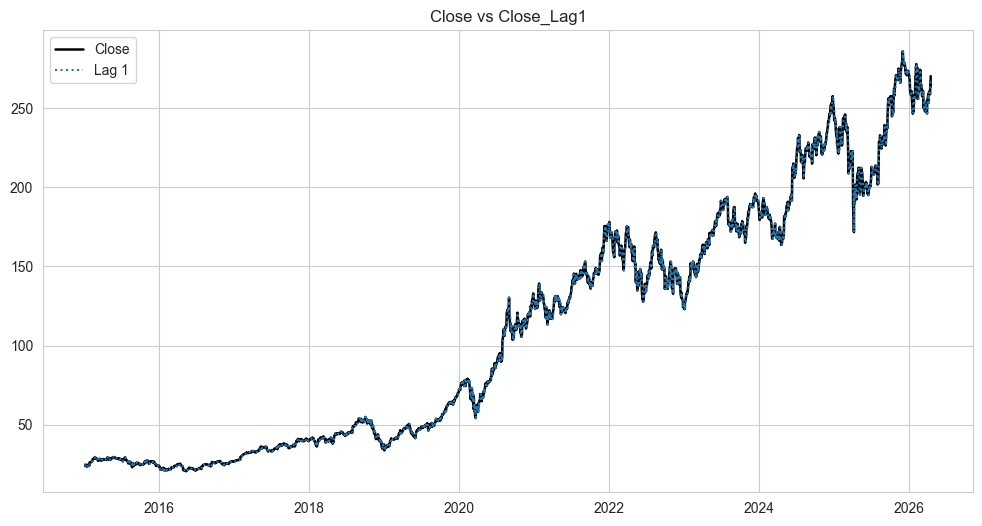

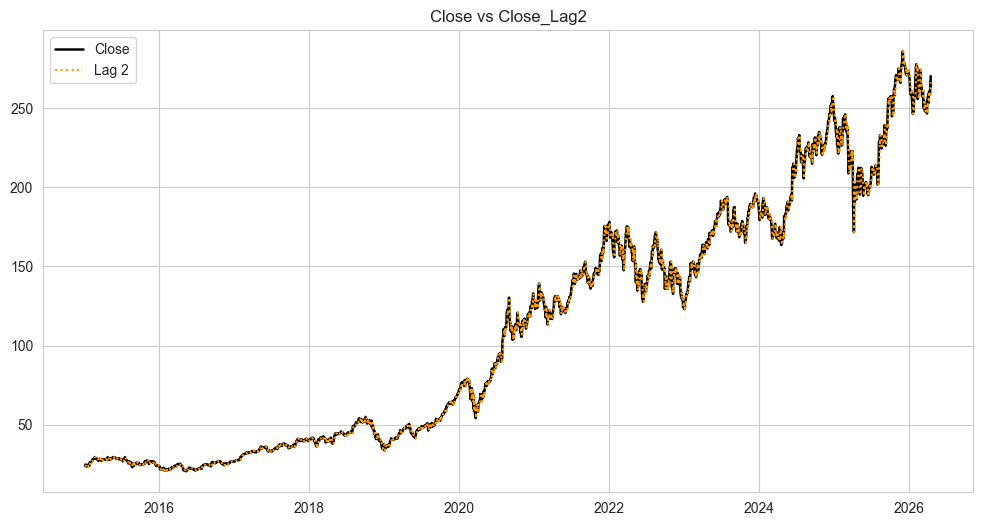

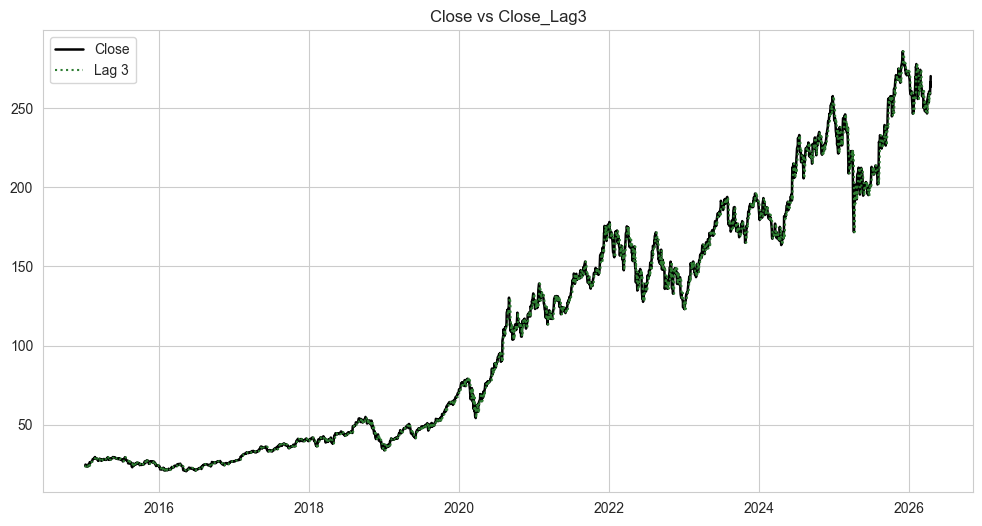

In [15]:
# Close vs Close_Lag1
plt.figure(figsize=(12,6))
plt.plot(df_ap['Close'], label='Close', color='#000000', linewidth=1.8)
plt.plot(df_ap['Close_Lag1'], label='Lag 1', color='#1f77b4', linestyle=":")
plt.title('Close vs Close_Lag1')
plt.legend()
plt.show()

# Close vs Close_Lag2
plt.figure(figsize=(12,6))
plt.plot(df_ap['Close'], label='Close', color='#000000', linewidth=1.8)
plt.plot(df_ap['Close_Lag2'], label='Lag 2', color='#FF9800', linestyle=":")
plt.title('Close vs Close_Lag2')
plt.legend()
plt.show()

# Close vs Close_Lag3
plt.figure(figsize=(12,6))
plt.plot(df_ap['Close'], label='Close', color='#000000', linewidth=1.8)
plt.plot(df_ap['Close_Lag3'], label='Lag 3', color='#2E7D32', linestyle=":")

plt.title('Close vs Close_Lag3')
plt.legend()
plt.show()

## **Distribution of Daily Returns (Momentum and Noise Analysis)**

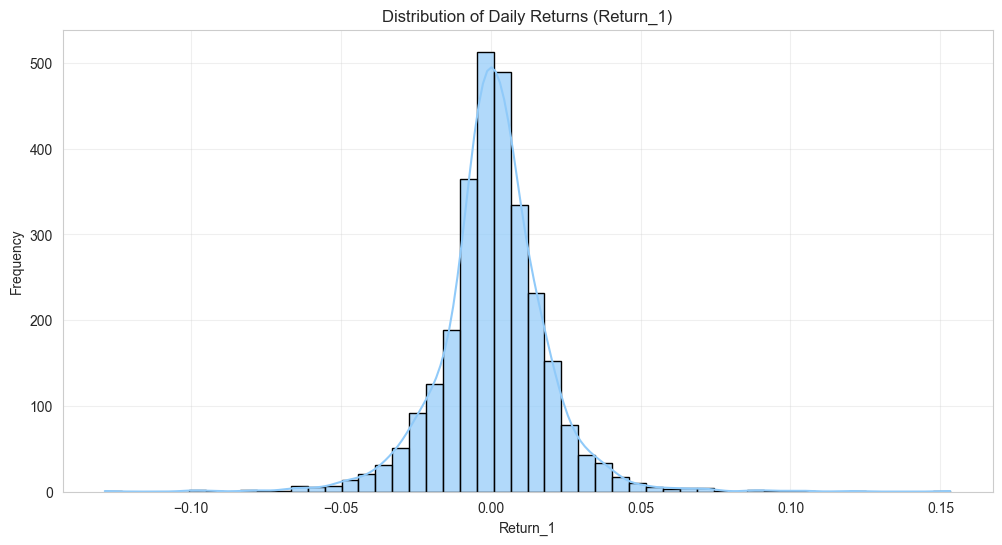

In [16]:
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.histplot(
    data=df_ap,
    x='Return_1',
    bins=50,
    kde=True,
    color='#90CAF9',   
    edgecolor='black',
    alpha=0.7
)

plt.title('Distribution of Daily Returns (Return_1)')
plt.xlabel('Return_1')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.show()


## **Feature Relationship Analysis (Correlation Heatmap)**

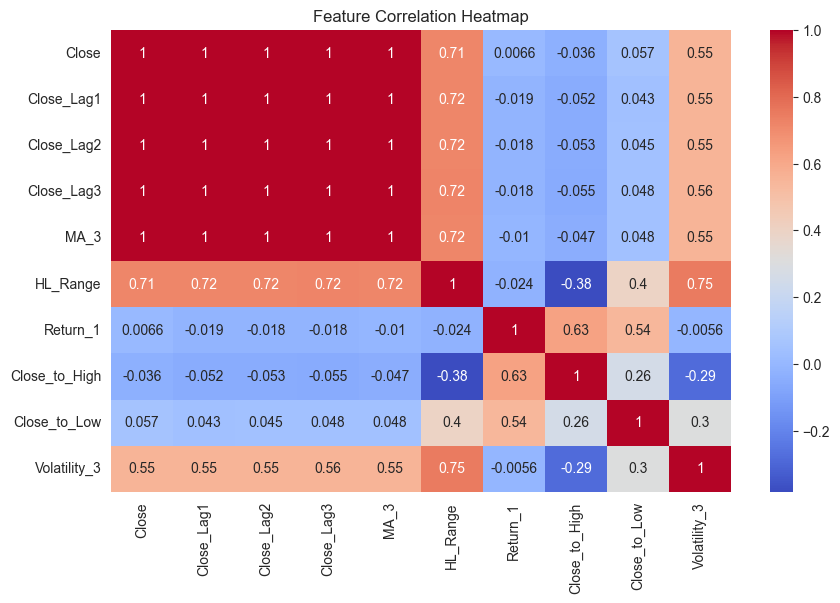

In [17]:
features = [
    'Close', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
    'MA_3', 'HL_Range', 'Return_1',
    'Close_to_High', 'Close_to_Low', 'Volatility_3'
]

corr = df_ap[features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## **Volatility Comparison: Intraday Range vs Rolling Volatility**

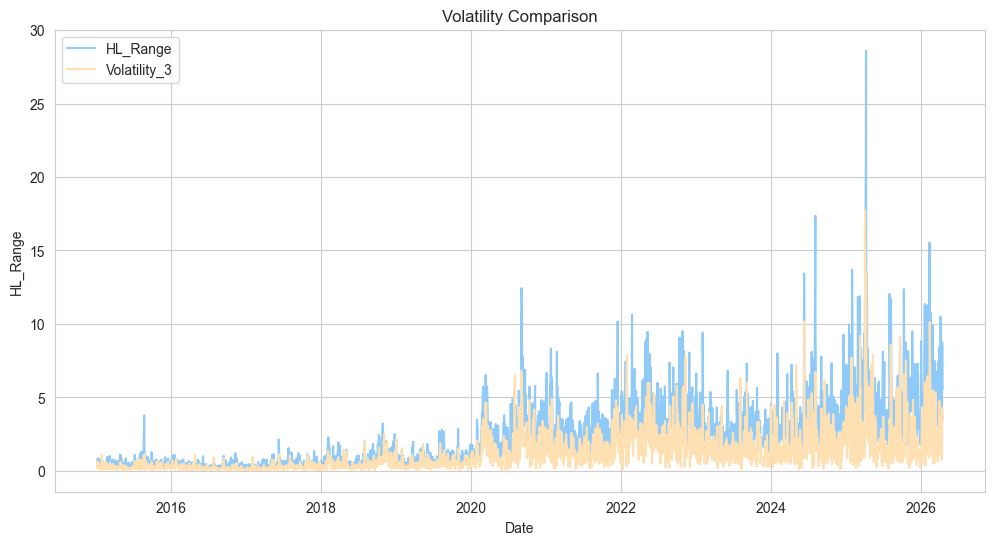

In [18]:
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    x=df_ap.index,
    y=df_ap['HL_Range'],
    label='HL_Range',
    color='#90CAF9'
)

sns.lineplot(
    x=df_ap.index,
    y=df_ap['Volatility_3'],
    label='Volatility_3',
    color='#FFE0B2'
)

plt.title('Volatility Comparison')
plt.legend()
plt.show()

## **Intraday Price Positioning Behavior (High vs Low Proximity)**

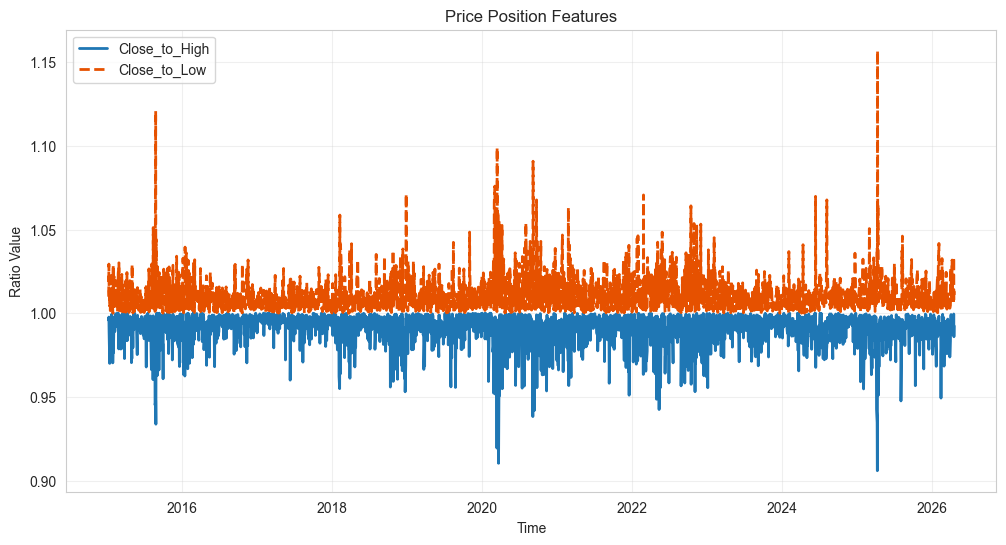

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    df_ap['Close_to_High'],
    label='Close_to_High',
    color='#1f77b4',   
    linewidth=2
)

plt.plot(
    df_ap['Close_to_Low'],
    label='Close_to_Low',
    color='#E65100',   
    linewidth=2,
    linestyle='--'     
)

plt.title('Price Position Features')
plt.xlabel('Time')
plt.ylabel('Ratio Value')
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## **Scatter Analysis: Intraday Position vs Short-Term Returns**

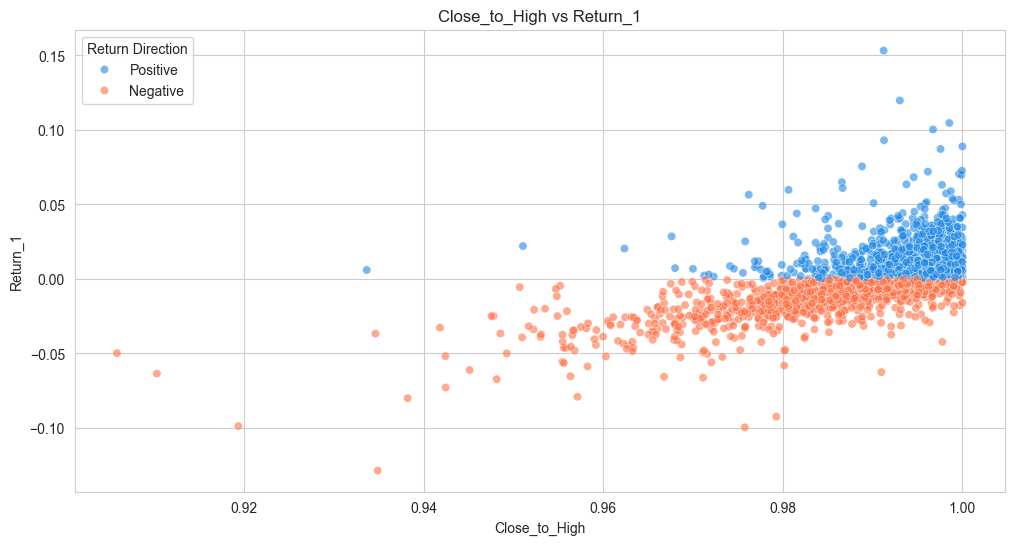

In [20]:
sns.set_style("whitegrid")

# Create color category
df_ap['Return_Sign'] = df_ap['Return_1'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_ap,
    x='Close_to_High',
    y='Return_1',
    hue='Return_Sign',
    palette = {'Positive': '#1E88E5',  'Negative': '#FF7043'},
    alpha=0.6
)

plt.title('Close_to_High vs Return_1')
plt.xlabel('Close_to_High')
plt.ylabel('Return_1')
plt.legend(title='Return Direction')
plt.show()

## **Low-End Price Position and Short-Term Returns**

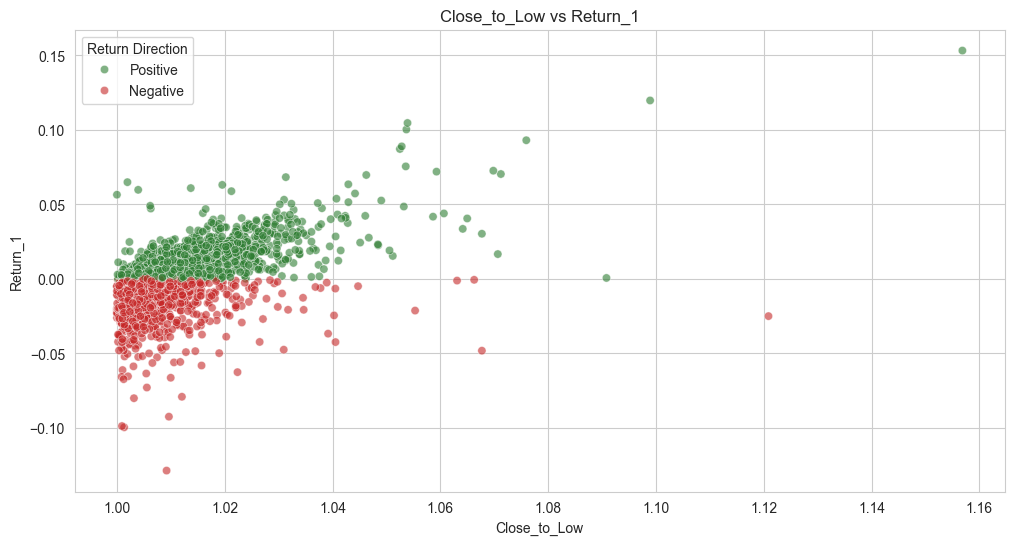

In [21]:
sns.set_style("whitegrid")

# Create directional feature
df_ap['Return_Sign'] = df_ap['Return_1'].apply(
    lambda x: 'Positive' if x >= 0 else 'Negative'
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_ap,
    x='Close_to_Low',
    y='Return_1',
    hue='Return_Sign',
    palette={'Positive': '#2E7D32', 'Negative': '#C62828'},
    alpha=0.6
)

plt.title('Close_to_Low vs Return_1')
plt.xlabel('Close_to_Low')
plt.ylabel('Return_1')
plt.legend(title='Return Direction')
plt.show()

## **Market Trend and Risk Dynamics Over Time**

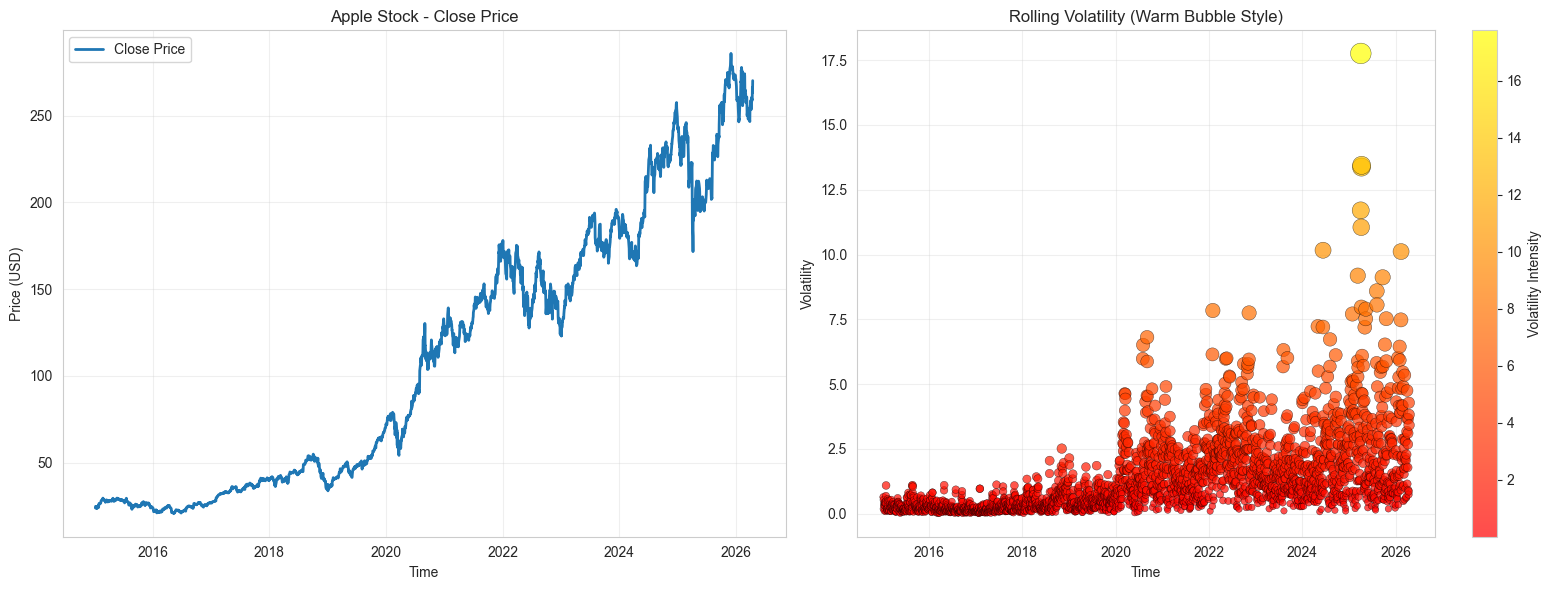

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharex=False)

# Close Price 
axes[0].plot(
    df_ap['Close'],
    label='Close Price',
    color='#1f77b4',
    linewidth=2
)

axes[0].set_title("Apple Stock - Close Price")
axes[0].set_ylabel("Price (USD)")
axes[0].set_xlabel("Time")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Volatility 
x = df_ap.index
y = df_ap['Volatility_3']

sizes = 20 + (y / y.max()) * 200

scatter = axes[1].scatter(
    x,
    y,
    c=y,
    cmap='autumn',
    s=sizes,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.3
)

axes[1].set_title("Rolling Volatility (Warm Bubble Style)")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Time")
axes[1].grid(alpha=0.3)

# Color bar
plt.colorbar(scatter, ax=axes[1], label="Volatility Intensity")

plt.tight_layout()
plt.show()

## **Preparing Data for Modeling**

In [23]:
# Ensure datetime index and sorting
df_ap.index = pd.to_datetime(df_ap.index)
df_ap = df_ap.sort_index()

### **Train-Validate-Test Split**  
**Train: 2015 to 2022,  Validate: 2023 to 2024,  Test: 2025**

In [24]:
# Time-based splits
train = df_ap.loc[:'2022']
val = df_ap.loc['2023':'2024']
test = df_ap.loc['2025':]

# Sanity check
print(f"Train: {train.index.min().strftime('%d-%m-%Y')} to {train.index.max().strftime('%d-%m-%Y')}")
print(f"Validate: {val.index.min().strftime('%d-%m-%Y')} to {val.index.max().strftime('%d-%m-%Y')}")
print(f"Test: {test.index.min().strftime('%d-%m-%Y')} to {test.index.max().strftime('%d-%m-%Y')}")

Train: 07-01-2015 to 30-12-2022
Validate: 03-01-2023 to 31-12-2024
Test: 02-01-2025 to 17-04-2026


### **Feature Description, Target Definition and Time-Based Train–Validation–Test Split with Models Training**

In [25]:
features = [
    'Open','High','Low','Volume',
    'Close_Lag1','Close_Lag2','Close_Lag3',
    'MA_3','HL_Range','Return_1',
    'Close_to_High','Close_to_Low',
    'Volatility_3'
]
df_ap['Target'] = df_ap['Close'].shift(-1)
df_ap.dropna(inplace=True)

X = df_ap[features]
y = df_ap['Target']

# Splits
X_train = X.loc[:'2022']
y_train = y.loc[:'2022']

X_val = X.loc['2023':'2024']
y_val = y.loc['2023':'2024']

X_test = X.loc['2025':]
y_test = y.loc['2025':]

# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## **Predictions**

In [26]:
# Train predictions
lr_train_pred = lr.predict(X_train)
rf_train_pred = rf.predict(X_train)

# Validation
lr_val_pred = lr.predict(X_val)
rf_val_pred = rf.predict(X_val)

# Test
lr_test_pred = lr.predict(X_test)
rf_test_pred = rf.predict(X_test)

## **Model Evaluation**

In [27]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

# Linear Regression
evaluate(y_val, lr_val_pred, "LR Validation")
evaluate(y_test, lr_test_pred, "LR Test")

# Random Forest
evaluate(y_val, rf_val_pred, "RF Validation")
evaluate(y_test, rf_test_pred, "RF Test")


LR Validation
RMSE: 2.5862421178746184
MAE: 1.9103077481942377
R2: 0.9914772677726313

LR Test
RMSE: 4.429221647337804
MAE: 2.991591202750799
R2: 0.9721665097643282

RF Validation
RMSE: 29.492906836396923
MAE: 19.443312212879437
R2: -0.10834672280983959

RF Test
RMSE: 69.26510551179143
MAE: 64.03858421041357
R2: -5.806781997571209


## **Visualization - Linear Regression**

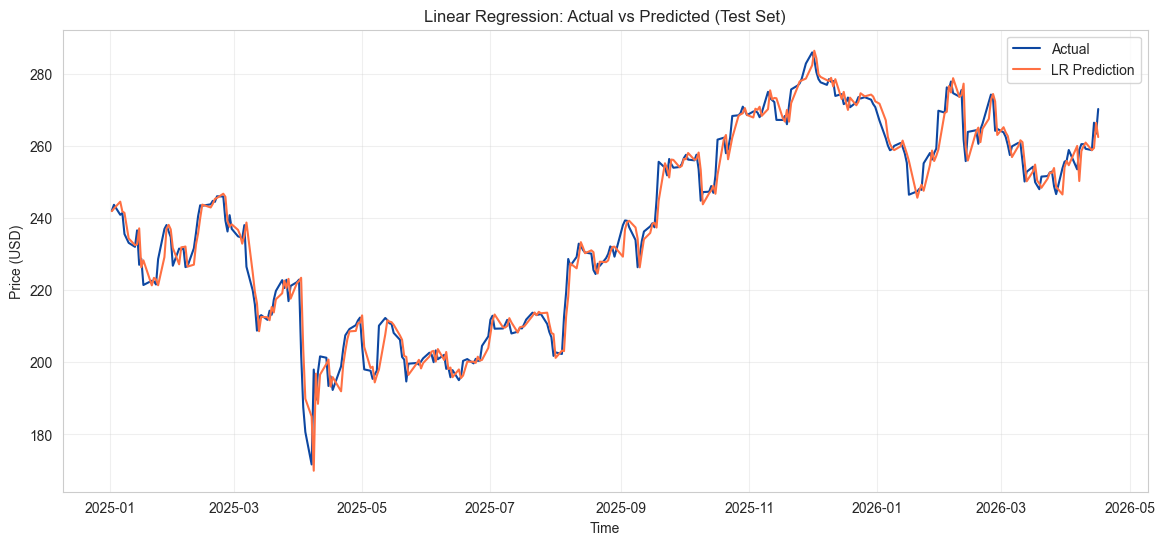

In [28]:
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test, label='Actual', color='#0D47A1')
plt.plot(y_test.index, lr_test_pred, label='LR Prediction', color='#FF7043')

plt.title('Linear Regression: Actual vs Predicted (Test Set)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **Visualization - Random Forest**

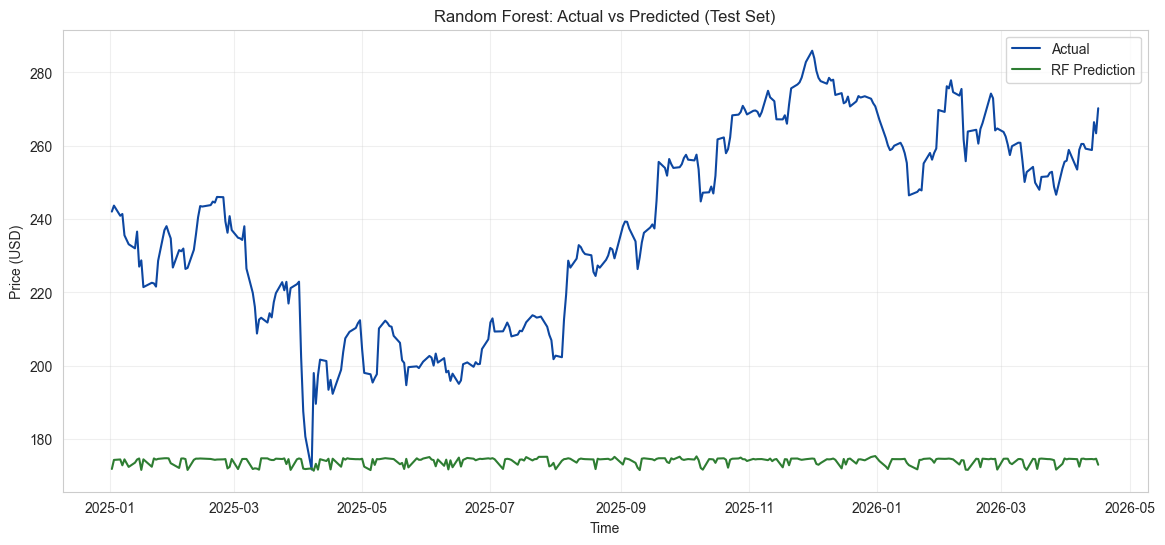

In [29]:
plt.figure(figsize=(14,6))

plt.plot(y_test.index, y_test, label='Actual', color='#0D47A1')
plt.plot(y_test.index, rf_test_pred, label='RF Prediction', color='#2E7D32')

plt.title('Random Forest: Actual vs Predicted (Test Set)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## **One-Day Prediction - Next Day Closing Stock**

In [30]:
# Last available data
last_data = X.iloc[-1:].copy()

lr_next = lr.predict(last_data)
rf_next = rf.predict(last_data)

print("Next Day Prediction (LR):", lr_next[0])
print("Next Day Prediction (RF):", rf_next[0])

Next Day Prediction (LR): 262.4534977467064
Next Day Prediction (RF): 172.96836196899415


## **Model Comparison**

In [31]:
# Example comparison (based on RMSE)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

if rf_rmse < lr_rmse:
    print("Random Forest is the better model")
else:
    print("Linear Regression is the better model")

Linear Regression is the better model


# **Final Conclusion**

# **On the basis of under-consideration dataset. Linear Regression Model outperformed**